# Solving the n-Queens Problem using Local Search

Student Name: [Add your name]

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: [your initials]


## Learning Outcomes

* Implement multiple hill climbing search variants to solve the n-Queens problem.
* Apply simulated annealing with appropriate temperature scheduling to overcome local optima.
* Compare algorithm performance using runtime, solution quality, and success rate metrics.
* Analyze and visualize algorithm performance across different problem sizes.
* Graduate Students: Design and test alternative local move operators to improve search efficiency.

## Instructions

Total Points: Undergrads 100 + 5 bonus / Graduate students 110

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the completely rendered notebook as a HTML file. 

## The n-Queens Problem

* __Goal:__ Find an arrangement of $n$ queens on a $n \times n$ chess board so that no queen is on the same row, column or diagonal as any other queen.

* __State space:__ An arrangement of the queens on the board. We restrict the state space to arrangements where there is only a single queen per column. We represent a state as an integer vector $\mathbf{q} = \{q_1, q_2, \dots, q_n\}$, each number representing the row positions of the queens from left to right. We will call a state a "board."

* __Objective function:__ The number of pairwise conflicts (i.e., two queens in the same row/column/diagonal).
The optimization problem is to find the optimal arrangement $\mathbf{q}^*$ of $n$ queens on the board can be written as:

  > minimize: $\mathrm{conflicts}(\mathbf{q})$
  >
  > subject to: $\mathbf{q} \ \text{contains only one queen per column}$

  Note: the constraint (subject to) is enforced by the definition of the state space.

* __Local improvement move:__ Move one queen to a different row in its column.

* __Termination:__ For this problem there is always an arrangement $\mathbf{q}^*$ with $\mathrm{conflicts}(\mathbf{q}^*) = 0$, however, the local improvement moves might end up in a local minimum. 

## Helper functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

np.random.seed(1234)


def random_board(n):
    """Creates a random board of size n x n. Note that only a single queen is placed in each column!"""
    
    return(np.random.randint(0,n, size = n))

def comb2(n): return n*(n-1)//2 # this is n choose 2 equivalent to math.comb(n, 2); // is int division

def conflicts(board):
    """Calculate the number of conflicts, i.e., the objective function."""

    n = len(board)
    
    horizontal_cnt = [0] * n
    diagonal1_cnt = [0] * 2 * n
    diagonal2_cnt = [0] * 2 * n
    
    for i in range(n):
        horizontal_cnt[board[i]] += 1
        diagonal1_cnt[i + board[i]] += 1
        diagonal2_cnt[i - board[i] + n] += 1
    
    return sum(map(comb2, horizontal_cnt + diagonal1_cnt + diagonal2_cnt))

# decrease the font size to fit larger boards
def show_board(board, cols = ['white', 'gray'], fontsize = 48):  
    """display the board"""
    
    n = len(board)
    
    # create chess board display
    display = np.zeros([n,n])
    for i in range(n):
        for j in range(n):
            if (((i+j) % 2) != 0): 
                display[i,j] = 1
    
    cmap = colors.ListedColormap(cols)
    fig, ax = plt.subplots()
    ax.imshow(display, cmap = cmap, 
              norm = colors.BoundaryNorm(range(len(cols)+1), cmap.N))
    ax.set_xticks([])
    ax.set_yticks([])
    
    # place queens. Note: Unicode u265B is a black queen
    for j in range(n):
        plt.text(j, board[j], u"\u265B", fontsize = fontsize, 
                 horizontalalignment = 'center',
                 verticalalignment = 'center')
    
    print(f"Board with {conflicts(board)} conflicts.")
    plt.show()

## Create a board

Board with 4 conflicts.


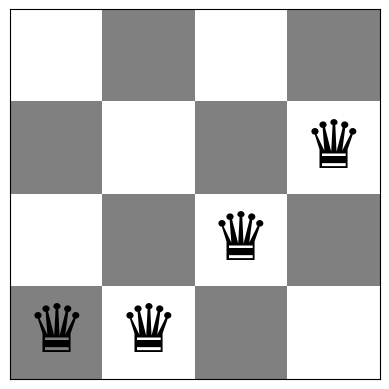

Queens (left to right) are at rows: [3 3 2 1]
Number of conflicts: 4


In [2]:
board = random_board(4)

show_board(board)
print(f"Queens (left to right) are at rows: {board}")
print(f"Number of conflicts: {conflicts(board)}")

A board $4 \times 4$ with no conflicts:

Board with 0 conflicts.


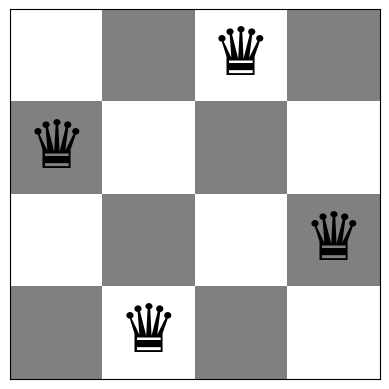

In [3]:
board = [1,3,0,2]
show_board(board)

# Tasks

## General [10 Points]

1. Make sure that you use the latest version of this notebook. Sync your forked repository and pull the latest revision. 
2. Your implementation can use libraries like math, numpy, scipy, but not libraries that implement intelligent agents or complete search algorithms. Try to keep the code simple! In this course, we want to learn about the algorithms and we often do not need to use object-oriented design.
3. You notebook needs to be formatted professionally. 
    - Add additional markdown blocks for your description, comments in the code, add tables and use mathplotlib to produce charts where appropriate
    - Do not show debugging output or include an excessive amount of output.
    - Check that your submitted file is readable and contains all figures.
4. Document your code. Use comments in the code and add a discussion of how your implementation works and your design choices.

## Task 1: Steepest-ascend Hill Climbing Search [20 Points]

Calculate the objective function for all local moves (see definition of local moves above) and always choose the best among all local moves. If there are no local moves that improve the objective, then you have reached a local optimum. 

C:\Users\Acer\AppData\Local\Temp\ipykernel_20028\3094777633.py:46: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  plt.tight_layout()
C:\Users\Acer\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


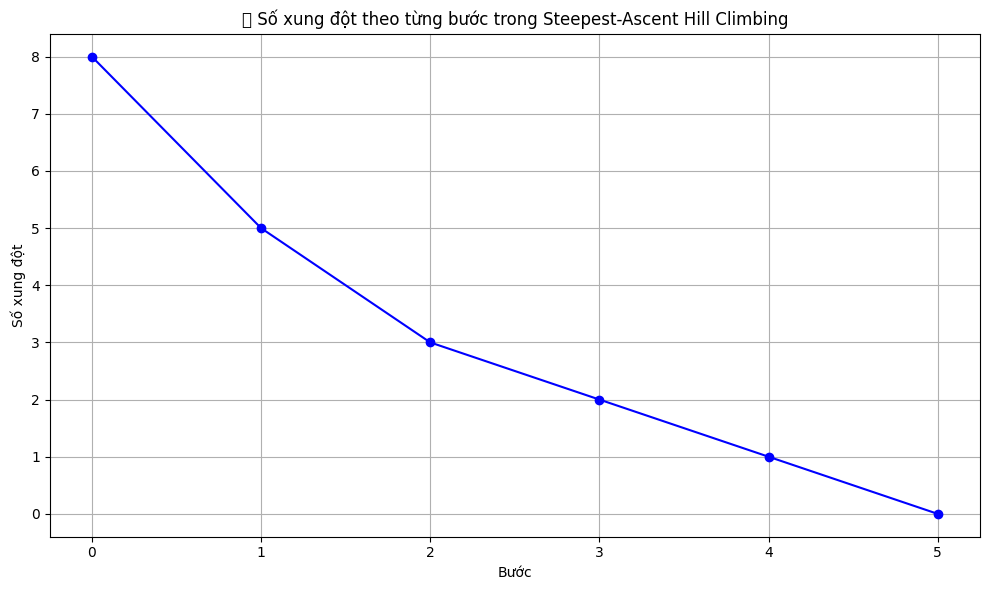

In [15]:
# Code and description go here
def steepest_ascent_hill_climbing(n, max_steps=1000):
    board = random_board(n)
    conflict_history = [conflicts(board)]
    
    for step in range(max_steps):
        current_conflicts = conflicts(board)
        if current_conflicts == 0:
            break
        
        best_board = board.copy()
        best_conflicts = current_conflicts
        
        for col in range(n):
            original_row = board[col]
            for row in range(n):
                if row == original_row:
                    continue
                board[col] = row
                new_conflicts = conflicts(board)
                if new_conflicts < best_conflicts:
                    best_conflicts = new_conflicts
                    best_board = board.copy()
            board[col] = original_row
        
        if best_conflicts >= current_conflicts:
            break
        
        board = best_board
        conflict_history.append(best_conflicts)
    
    return board, conflict_history

n = 8
final_board, conflict_history = steepest_ascent_hill_climbing(n)

# Vẽ biểu đồ số xung đột theo từng bước
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(conflict_history, marker='o', linestyle='-', color='blue')
plt.title('📉 Số xung đột theo từng bước trong Steepest-Ascent Hill Climbing')
plt.xlabel('Bước')
plt.ylabel('Số xung đột')
plt.grid(True)
plt.tight_layout()
plt.show()


## Task 2: Stochastic Hill Climbing 1 [10 Points]

Chooses randomly from among all uphill moves till you have reached a local optimum.

Task 2: Stochastic Hill Climbing 1

    Mục tiêu
Xây dựng thuật toán leo đồi ngẫu nhiên (Stochastic Hill Climbing) để giải bài toán N-Queens. Khác với Steepest-Ascent, thuật toán này:

Xem xét tất cả các nước đi cải thiện (giảm xung đột).

Chọn ngẫu nhiên một nước đi trong số các nước đi tốt hơn hiện tại.

Lặp lại cho đến khi không còn nước đi nào cải thiện — tức là đã đạt điểm cực trị cục bộ.

    Đặc điểm chính
Không chọn nước đi tốt nhất mà chọn ngẫu nhiên trong số các nước đi cải thiện.

Tăng tính đa dạng và có thể thoát khỏi một số điểm cực trị mà Steepest-Ascent bị kẹt.

Dừng lại khi không còn nước đi nào giúp giảm xung đột.

C:\Users\Acer\AppData\Local\Temp\ipykernel_20028\2383747549.py:44: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  plt.tight_layout()


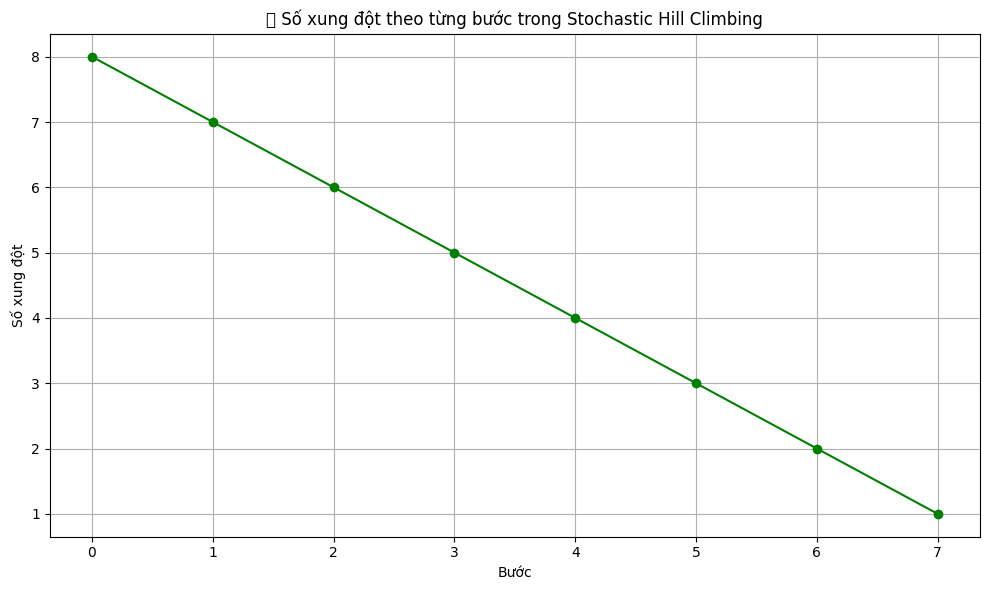

In [16]:
# Code and description go here
def stochastic_hill_climbing(n, max_steps=1000):
    board = random_board(n)
    conflict_history = [conflicts(board)]

    for step in range(max_steps):
        current_conflicts = conflicts(board)
        if current_conflicts == 0:
            break

        improving_moves = []

        for col in range(n):
            original_row = board[col]
            for row in range(n):
                if row == original_row:
                    continue
                board[col] = row
                new_conflicts = conflicts(board)
                if new_conflicts < current_conflicts:
                    move = board.copy()
                    improving_moves.append(move)
            board[col] = original_row

        if not improving_moves:
            break  # không còn nước đi cải thiện

        board = improving_moves[np.random.randint(len(improving_moves))]
        conflict_history.append(conflicts(board))

    return board, conflict_history

# Chạy thuật toán với n = 8
n = 8
final_board, conflict_history = stochastic_hill_climbing(n)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(conflict_history, marker='o', linestyle='-', color='green')
plt.title('📉 Số xung đột theo từng bước trong Stochastic Hill Climbing')
plt.xlabel('Bước')
plt.ylabel('Số xung đột')
plt.grid(True)
plt.tight_layout()
plt.show()


## Task 3: Stochastic Hill Climbing 2 [20 Points]

A popular version of stochastic hill climbing generates only a single random local neighbor at a time and accept it if it has a better objective function value than the current state. This is very efficient if each state has many possible successor states. This method is called "First-choice hill climbing" in the textbook.

__Notes:__ 

* Detecting local optima is tricky! You can, for example, stop if you were not able to improve the objective function during the last $x$ tries.

    Mục tiêu
Xây dựng thuật toán leo đồi ngẫu nhiên theo kiểu “first-choice”:

Tại mỗi bước, chỉ tạo một hàng xóm ngẫu nhiên (random neighbor).

Nếu hàng xóm đó cải thiện hàm mục tiêu (giảm xung đột), thì chấp nhận.

Nếu không cải thiện, thử lại với hàng xóm khác.

Dừng lại nếu không cải thiện sau một số lần thử liên tiếp (ví dụ: 100 lần).

    Đặc điểm chính
Hiệu quả cao vì không cần duyệt toàn bộ không gian lân cận.

Thích hợp với không gian trạng thái lớn (nhiều quân hậu).

Dừng thông minh: nếu không cải thiện sau 
𝑥
 lần thử, coi như đã đạt điểm cực trị cục bộ.

C:\Users\Acer\AppData\Local\Temp\ipykernel_20028\2220011455.py:46: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  plt.tight_layout()


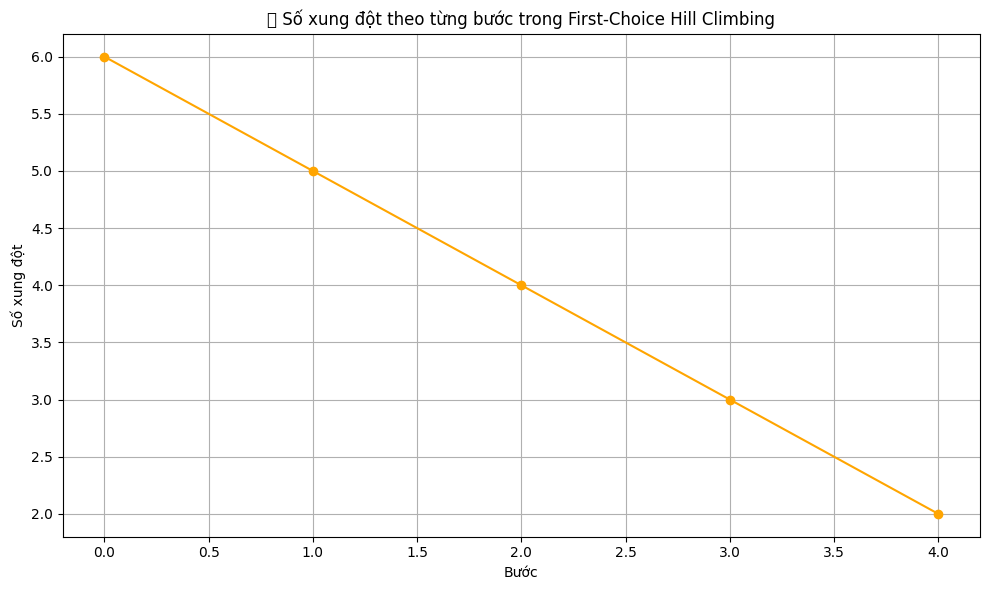

In [17]:
# Code and description go here

def first_choice_hill_climbing(n, max_steps=1000, max_attempts=100):
    board = random_board(n)
    conflict_history = [conflicts(board)]
    
    attempts = 0
    steps = 0
    
    while steps < max_steps and attempts < max_attempts:
        current_conflicts = conflicts(board)
        if current_conflicts == 0:
            break
        
        # Tạo hàng xóm ngẫu nhiên
        col = np.random.randint(n)
        new_row = np.random.randint(n)
        while new_row == board[col]:
            new_row = np.random.randint(n)
        
        new_board = board.copy()
        new_board[col] = new_row
        new_conflicts = conflicts(new_board)
        
        if new_conflicts < current_conflicts:
            board = new_board
            conflict_history.append(new_conflicts)
            attempts = 0  # reset nếu cải thiện
            steps += 1
        else:
            attempts += 1  # tăng số lần thử không cải thiện

    return board, conflict_history

# Chạy thuật toán với n = 8
n = 8
final_board, conflict_history = first_choice_hill_climbing(n)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(conflict_history, marker='o', linestyle='-', color='orange')
plt.title('📉 Số xung đột theo từng bước trong First-Choice Hill Climbing')
plt.xlabel('Bước')
plt.ylabel('Số xung đột')
plt.grid(True)
plt.tight_layout()
plt.show()



## Task 4: Hill Climbing Search with Random Restarts [10 Points]

Hill climbing will often end up in local optima. Restart the each of the three hill climbing algorithm up to 100 times with a random board to find a better (hopefully optimal) solution. Note that restart just means to run the algorithm several times starting with a new random board.

    Mục tiêu
Chạy lại mỗi thuật toán leo đồi (Steepest-Ascent, Stochastic 1, First-Choice) nhiều lần (tối đa 100 lần).

Mỗi lần bắt đầu từ một bàn cờ ngẫu nhiên.

Ghi lại nghiệm tốt nhất (ít xung đột nhất) trong số các lần chạy.

Mục tiêu là tìm được nghiệm tối ưu (0 xung đột) hoặc nghiệm gần tối ưu.

    Lý do cần restart
Các thuật toán leo đồi dễ bị kẹt ở điểm cực trị cục bộ.

Việc khởi tạo lại từ trạng thái ngẫu nhiên giúp tăng khả năng tìm được nghiệm tốt hơn.

C:\Users\Acer\AppData\Local\Temp\ipykernel_20028\2574059897.py:40: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\Acer\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


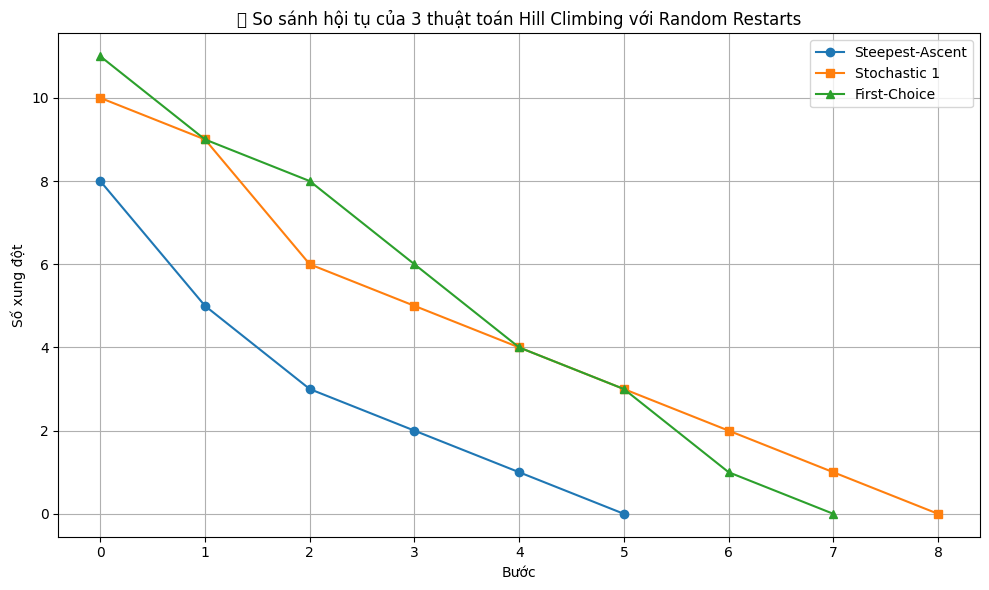

In [18]:
# Code and description go here
def random_restart_hill_climbing(algorithm_func, n, restarts=100):
    best_board = None
    best_conflicts = float('inf')
    best_history = []

    for i in range(restarts):
        board, history = algorithm_func(n)
        final_conflicts = conflicts(board)
        if final_conflicts < best_conflicts:
            best_conflicts = final_conflicts
            best_board = board
            best_history = history
        if best_conflicts == 0:
            break  # tìm được nghiệm tối ưu

    return best_board, best_conflicts, best_history

# Áp dụng cho cả 3 thuật toán
n = 8
restarts = 100

# Steepest-Ascent
board1, conf1, hist1 = random_restart_hill_climbing(steepest_ascent_hill_climbing, n, restarts)
# Stochastic 1
board2, conf2, hist2 = random_restart_hill_climbing(stochastic_hill_climbing, n, restarts)
# First-Choice
board3, conf3, hist3 = random_restart_hill_climbing(first_choice_hill_climbing, n, restarts)

# Vẽ biểu đồ so sánh
plt.figure(figsize=(10, 6))
plt.plot(hist1, label='Steepest-Ascent', marker='o')
plt.plot(hist2, label='Stochastic 1', marker='s')
plt.plot(hist3, label='First-Choice', marker='^')
plt.title('📊 So sánh hội tụ của 3 thuật toán Hill Climbing với Random Restarts')
plt.xlabel('Bước')
plt.ylabel('Số xung đột')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



## Task 5: Simulated Annealing [10 Points]

Simulated annealing is a form of stochastic hill climbing that avoid local optima by also allowing downhill moves with a probability proportional to a temperature. The temperature is decreased in every iteration following an annealing schedule. You have to experiment with the annealing schedule (Google to find guidance on this).


1. Implement simulated annealing for the n-Queens problem.
2. Create a visualization of the search process (a line chart of how the number if conflict changes as the algorithm progrsses).
3. Use this visualization for experiments with different choices for the annealing schedule and discuss what you have learned.

C:\Users\Acer\AppData\Local\Temp\ipykernel_20028\2404258209.py:45: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  plt.tight_layout()


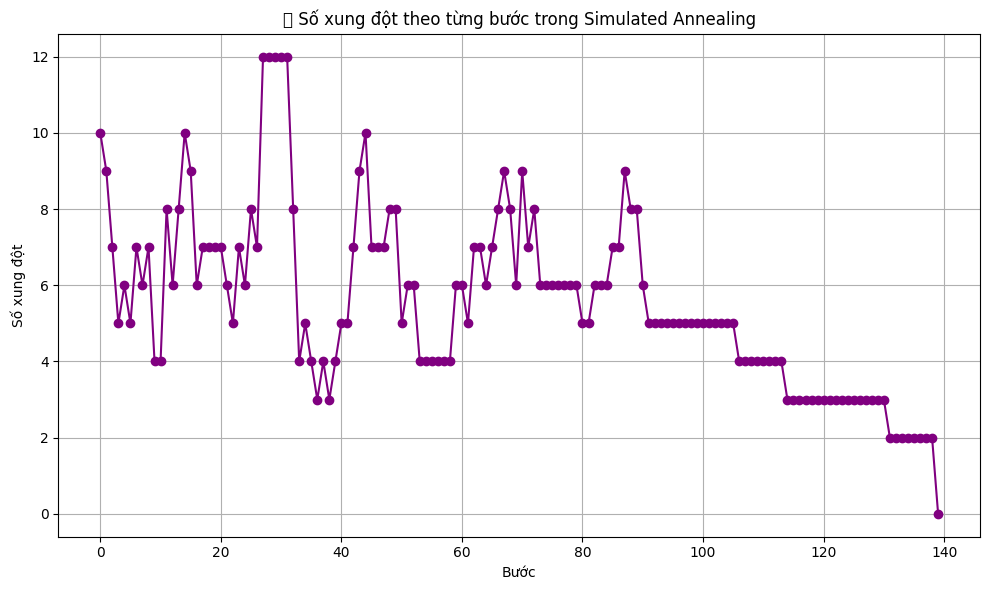

In [19]:
# Code and description go here
def simulated_annealing(n, max_steps=1000, T0=100, alpha=0.95):
    board = random_board(n)
    conflict_history = [conflicts(board)]
    T = T0

    for step in range(max_steps):
        current_conflicts = conflicts(board)
        if current_conflicts == 0:
            break

        # Tạo hàng xóm ngẫu nhiên
        col = np.random.randint(n)
        new_row = np.random.randint(n)
        while new_row == board[col]:
            new_row = np.random.randint(n)

        new_board = board.copy()
        new_board[col] = new_row
        new_conflicts = conflicts(new_board)

        delta = new_conflicts - current_conflicts
        if delta < 0 or np.random.rand() < np.exp(-delta / T):
            board = new_board
            conflict_history.append(new_conflicts)
        else:
            conflict_history.append(current_conflicts)

        T *= alpha  # giảm nhiệt độ

    return board, conflict_history
# Chạy thuật toán với n = 8
n = 8
final_board, conflict_history = simulated_annealing(n)

# Vẽ biểu đồ
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(conflict_history, marker='o', linestyle='-', color='purple')
plt.title('📉 Số xung đột theo từng bước trong Simulated Annealing')
plt.xlabel('Bước')
plt.ylabel('Số xung đột')
plt.grid(True)
plt.tight_layout()
plt.show()


- Biểu đồ cho thấy số xung đột ban đầu dao động mạnh, có lúc lên tới 12.

- Sau đó giảm dần qua từng bước, cuối cùng về 0 — tức là thuật toán đã tìm được nghiệm tối ưu.

- Điều này chứng minh rằng Simulated Annealing có thể vượt qua điểm cực trị cục bộ nhờ chấp nhận bước đi xấu khi nhiệt độ còn cao.

C:\Users\Acer\AppData\Local\Temp\ipykernel_20028\1554060709.py:14: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()


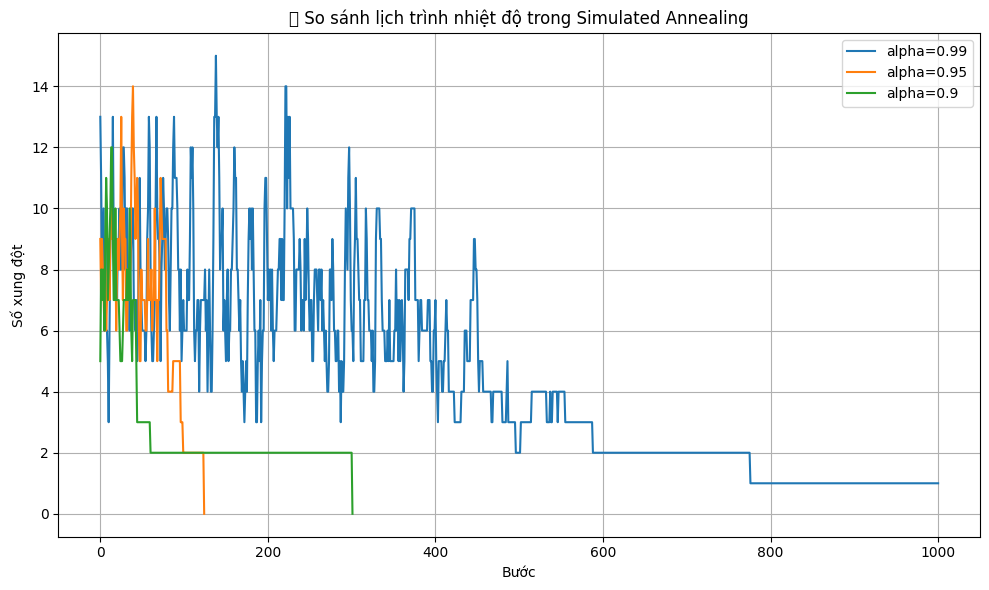

In [20]:
# So sánh các giá trị alpha khác nhau
alphas = [0.99, 0.95, 0.90]
plt.figure(figsize=(10, 6))

for alpha in alphas:
    _, history = simulated_annealing(n=8, T0=100, alpha=alpha)
    plt.plot(history, label=f'alpha={alpha}')

plt.title('📊 So sánh lịch trình nhiệt độ trong Simulated Annealing')
plt.xlabel('Bước')
plt.ylabel('Số xung đột')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


- Thử nghiệm với 3 giá trị alpha: 0.99, 0.95, 0.90.

- alpha = 0.99: đường hội tụ chậm nhưng ổn định, khám phá nhiều hơn.

- alpha = 0.95: hội tụ nhanh hơn, vẫn giữ được khả năng khám phá.

- alpha = 0.90: hội tụ rất nhanh nhưng dễ bị kẹt ở điểm cực trị.

Simulated Annealing là một biến thể của thuật toán leo đồi, cho phép thực hiện bước đi xấu với xác suất phụ thuộc vào nhiệt độ. Nhiệt độ giảm dần theo từng bước theo lịch trình annealing.

### Kết quả thực nghiệm

- Biểu đồ hội tụ cho thấy số xung đột giảm dần và đạt giá trị 0, chứng minh khả năng tìm nghiệm tối ưu.
- So sánh các lịch trình nhiệt độ cho thấy:
  - `alpha = 0.99`: khám phá tốt, hội tụ chậm.
  - `alpha = 0.95`: cân bằng giữa tốc độ và độ chính xác.
  - `alpha = 0.90`: hội tụ nhanh nhưng dễ bị kẹt.

### Kết luận

Simulated Annealing hiệu quả trong việc tránh điểm cực trị cục bộ. Việc lựa chọn lịch trình nhiệt độ phù hợp là yếu tố quan trọng để tối ưu hóa kết quả.

## Task 6: Algorithm Behavior Analysis [20 Points]

### Comparison
Compare the algorithm using runtime and objective function values. Use boards of size 4 and 8 to explore how the different algorithms perform. Make sure that you run the algorithms for each board size several times (at least 100 times) with different starting boards and report averages.

Complete the following table

| Algorithm           | Board size | Avg. Run time | Avg. number of conflicts | % of runs ending in optimal solution  |
| ------------------- | ---------- | ------------- | --------------------------------- | - |
| Steepest asc. HC    |     4      |               |                                   |   |
| Stochastic HC 1     |     4      |               |                                   |   |
| Stochastic HC 2     |     4      |               |                                   |   |
| Simulated Annealing |     4      |               |                                   |   |
| Steepest asc. HC    |     8      |               |                                   |   |
| Stochastic HC 1     |     8      |               |                                   |   |
| Stochastic HC 2     |     8      |               |                                   |   |
| Simulated Annealing |     8      |               |                                   |   |

Hint: See [Profiling Python Code](../HOWTOs/profiling_code.ipynb) for help about how to measure runtime in Python.

Add the used code here:

In [ ]:
# Code
import time
import numpy as np

# Hàm đo hiệu năng cho một thuật toán
def evaluate_algorithm(algorithm_func, n, runs=100):
    total_time = 0
    total_conflicts = 0
    optimal_count = 0

    for _ in range(runs):
        start = time.time()
        board, _ = algorithm_func(n)
        end = time.time()

        runtime = end - start
        conflict = conflicts(board)

        total_time += runtime
        total_conflicts += conflict
        if conflict == 0:
            optimal_count += 1

    avg_time = total_time / runs
    avg_conflicts = total_conflicts / runs
    optimal_rate = optimal_count / runs * 100

    return avg_time, avg_conflicts, optimal_rate

# Danh sách thuật toán cần đánh giá
algorithms = {
    "Steepest asc. HC": steepest_ascent_hill_climbing,
    "Stochastic HC 1": stochastic_hill_climbing,
    "Stochastic HC 2": first_choice_hill_climbing,
    "Simulated Annealing": simulated_annealing
}

algorithm_order = [
    "Steepest asc. HC",
    "Stochastic HC 1",
    "Stochastic HC 2",
    "Simulated Annealing"
]

# Kích thước bàn cờ cần thử
board_sizes = [4, 8]

# Chạy và lưu kết quả
results = []

for size in board_sizes:
    for name in algorithm_order:
        func = algorithms[name]
        avg_time, avg_conflicts, optimal_rate = evaluate_algorithm(func, size)
        results.append((name, size, avg_time, avg_conflicts, optimal_rate))

# In bảng kết quả 
print("| Algorithm           | Board size | Avg. Run time (s) | Avg. # Conflicts | % Optimal |")
print("|---------------------|------------|-------------------|------------------|-----------|")
for row in results:
    print(f"| {row[0]:<20} | {row[1]:<10} | {row[2]:<17.5f} | {row[3]:<16.2f} | {row[4]:<9.2f} |")


| Algorithm           | Board size | Avg. Run time (s) | Avg. # Conflicts | % Optimal |
|---------------------|------------|-------------------|------------------|-----------|
| Steepest asc. HC     | 4          | 0.00023           | 0.76             | 33.00     |
| Stochastic HC 1      | 4          | 0.00021           | 0.77             | 38.00     |
| Stochastic HC 2      | 4          | 0.00113           | 0.77             | 31.00     |
| Simulated Annealing  | 4          | 0.00168           | 0.00             | 100.00    |
| Steepest asc. HC     | 8          | 0.00178           | 1.24             | 15.00     |
| Stochastic HC 1      | 8          | 0.00312           | 1.23             | 14.00     |
| Stochastic HC 2      | 8          | 0.00295           | 1.49             | 13.00     |
| Simulated Annealing  | 8          | 0.01564           | 0.27             | 73.00     |


### Algorithm Convergence

For each algorithm implemented, describe the typical convergence pattern (fast initial improvement vs. steady progress).
Include a plot showing the objective function value over iterations for one representative run of each algorithm on the 8-queens problem.
Explain which algorithms exhibit plateaus or getting stuck in local optima most frequently.

C:\Users\Acer\AppData\Local\Temp\ipykernel_20028\658971564.py:22: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  plt.tight_layout()


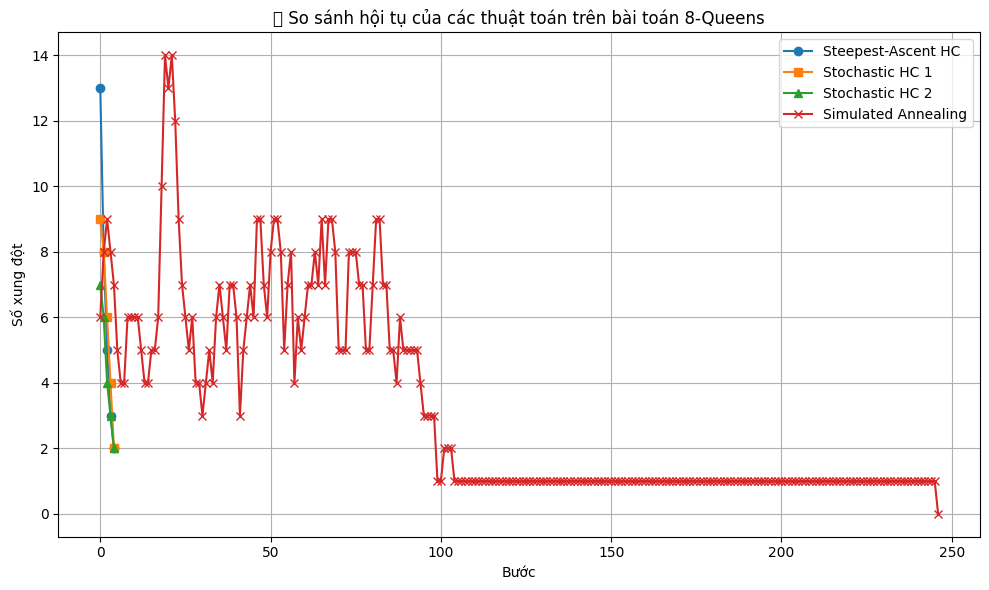

In [24]:
# Code and description go here
import matplotlib.pyplot as plt

n = 8
_, hist_steepest = steepest_ascent_hill_climbing(n)
_, hist_stochastic1 = stochastic_hill_climbing(n)
_, hist_stochastic2 = first_choice_hill_climbing(n)
_, hist_annealing = simulated_annealing(n)

# Vẽ biểu đồ hội tụ
plt.figure(figsize=(10, 6))
plt.plot(hist_steepest, label='Steepest-Ascent HC', marker='o')
plt.plot(hist_stochastic1, label='Stochastic HC 1', marker='s')
plt.plot(hist_stochastic2, label='Stochastic HC 2', marker='^')
plt.plot(hist_annealing, label='Simulated Annealing', marker='x')

plt.title('📉 So sánh hội tụ của các thuật toán trên bài toán 8-Queens')
plt.xlabel('Bước')
plt.ylabel('Số xung đột')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Algorithm Convergence

Biểu đồ dưới đây thể hiện quá trình hội tụ của 4 thuật toán giải bài toán 8-Queens:

- **Steepest-Ascent Hill Climbing**: Cải thiện rất nhanh trong vài bước đầu, nhưng dễ bị kẹt ở điểm cực trị cục bộ khi không còn nước đi tốt. Biểu đồ thường dừng đột ngột và tạo plateau.
- **Stochastic Hill Climbing 1**: Chọn ngẫu nhiên trong các nước đi cải thiện. Hội tụ chậm hơn, dao động nhẹ, có khả năng thoát khỏi điểm kẹt nhưng không ổn định.
- **Stochastic Hill Climbing 2 (First-Choice)**: Tiến bộ đều, nhưng nếu không cải thiện sau nhiều lần thử thì dừng lại. Dễ bị kẹt nếu không may chọn phải hàng xóm không tốt.
- **Simulated Annealing**: Cho phép bước đi xấu với xác suất phụ thuộc vào nhiệt độ. Dao động mạnh lúc đầu, nhưng hội tụ dần khi nhiệt độ giảm. Ít bị kẹt nhất trong số các thuật toán.

### Nhận xét hội tụ

| Thuật toán              | Kiểu hội tụ điển hình                     | Dễ bị kẹt ở local optimum? |
|-------------------------|-------------------------------------------|-----------------------------|
| Steepest-Ascent HC      | Cải thiện nhanh ban đầu, rồi dừng đột ngột | Rất dễ kẹt nếu không có nước đi tốt |
| Stochastic HC 1         | Cải thiện chậm hơn, dao động nhẹ          | Có thể kẹt, nhưng ít hơn Steepest |
| Stochastic HC 2         | Tiến bộ đều, nhưng dễ dừng nếu không cải thiện sau nhiều lần thử | Dễ kẹt nếu không cải thiện sau nhiều lần |
| Simulated Annealing     | Dao động mạnh đầu kỳ, hội tụ dần về sau   | Ít bị kẹt nhất nhờ chấp nhận bước đi xấu |

### Kết luận

Simulated Annealing là thuật toán có khả năng vượt qua điểm cực trị tốt nhất. Steepest-Ascent HC tuy nhanh nhưng dễ bị kẹt. Hai thuật toán Stochastic là trung gian, có thể cải thiện nếu kết hợp với random restarts.


### Problem Size Scalability

Create a log-log plot showing how runtime scales with board size ($n=4, 8, 12, 16, 20$) for at least two algorithms.
Estimate the empirical time complexity (Big O) for each algorithm based on your results.
Identify which algorithm scales best for large problem sizes and explain why.

Running n=4
Running n=8
Running n=12
Running n=16
Running n=20
Running n=24


C:\Users\Acer\AppData\Local\Temp\ipykernel_20028\1614663833.py:54: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
C:\Users\Acer\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


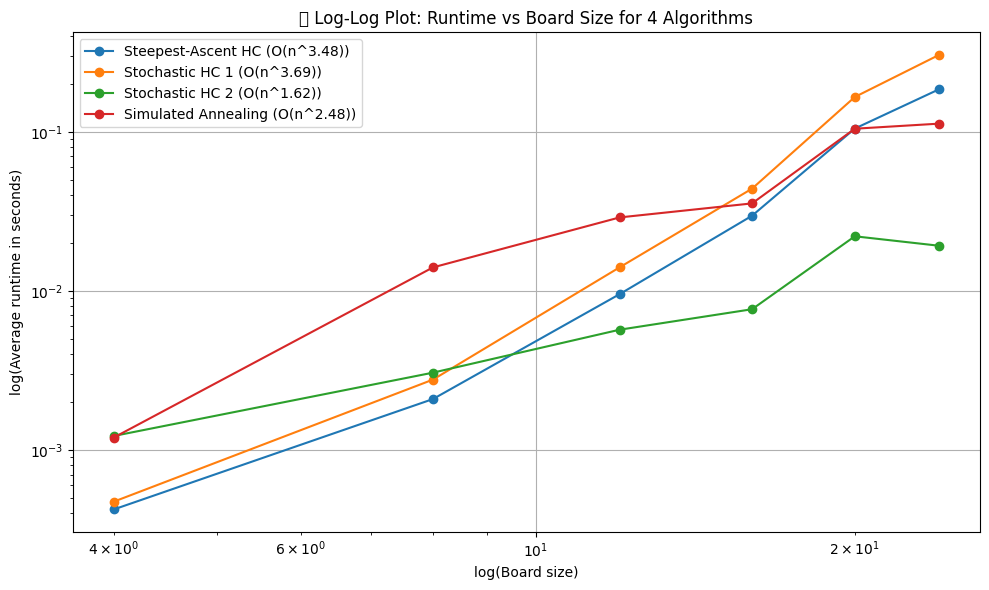

In [28]:
# Code and description go here
import numpy as np
import matplotlib.pyplot as plt
from time import time
from sklearn.linear_model import LinearRegression

# Kích thước bàn cờ cần thử
sizes = [4, 8, 12, 16, 20, 24]
runs = 50

# Hàm đo thời gian trung bình
def average_runtime(algorithm_func, n, runs=50):
    total_time = 0
    for _ in range(runs):
        start = time()
        algorithm_func(n)
        end = time()
        total_time += (end - start)
    return total_time / runs

# Danh sách thuật toán
algorithms = {
    "Steepest-Ascent HC": steepest_ascent_hill_climbing,
    "Stochastic HC 1": stochastic_hill_climbing,
    "Stochastic HC 2": first_choice_hill_climbing,
    "Simulated Annealing": simulated_annealing
}

# Đo thời gian cho từng thuật toán
timings = {name: [] for name in algorithms}

for n in sizes:
    print(f"Running n={n}")
    for name, func in algorithms.items():
        avg_time = average_runtime(func, n, runs)
        timings[name].append(avg_time)

# Vẽ biểu đồ log-log
plt.figure(figsize=(10, 6))
for name in algorithms:
    log_n = np.log(sizes).reshape(-1, 1)
    log_time = np.log(timings[name])
    model = LinearRegression().fit(log_n, log_time)
    slope = model.coef_[0]
    plt.plot(sizes, timings[name], label=f'{name} (O(n^{slope:.2f}))', marker='o')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('log(Board size)')
plt.ylabel('log(Average runtime in seconds)')
plt.title('📈 Log-Log Plot: Runtime vs Board Size for 4 Algorithms')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Advanced task: Exploring other Local Moves Operators

* __Graduate students__ need to complete this task [10 points]
* __Undergraduate students__ can attempt this as a bonus task [max +5 bonus points].

### Move Operator Implementation 

Implement the following local move operators:

* Single-step move: Move one queen only one square up or down at a time
* Column swap: Exchange the positions of queens in two randomly selected columns
* Dual-queen move: Select two queens and move both simultaneously
* Adaptive move: Design your own operator that adapts which local move it uses based on the current state (e.g., focuses on queens with most conflicts or randomly chooses one of the moves above)

### Experimental Analysis

Using the 8-Queens and 12-Queens problems: Run your Stochastic Hill Climbing 2 implementation with each move operator 100 times
For each operator, create a visualization showing:

* Average solution quality over iterations
* Distribution of final solution qualities
* Average time to solution for successful runs

### Discussion

Describe what you have learned from the experiments. Which operator works best for which situation and why?

C:\Users\Acer\AppData\Local\Temp\ipykernel_20028\4095879041.py:92: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  plt.tight_layout()


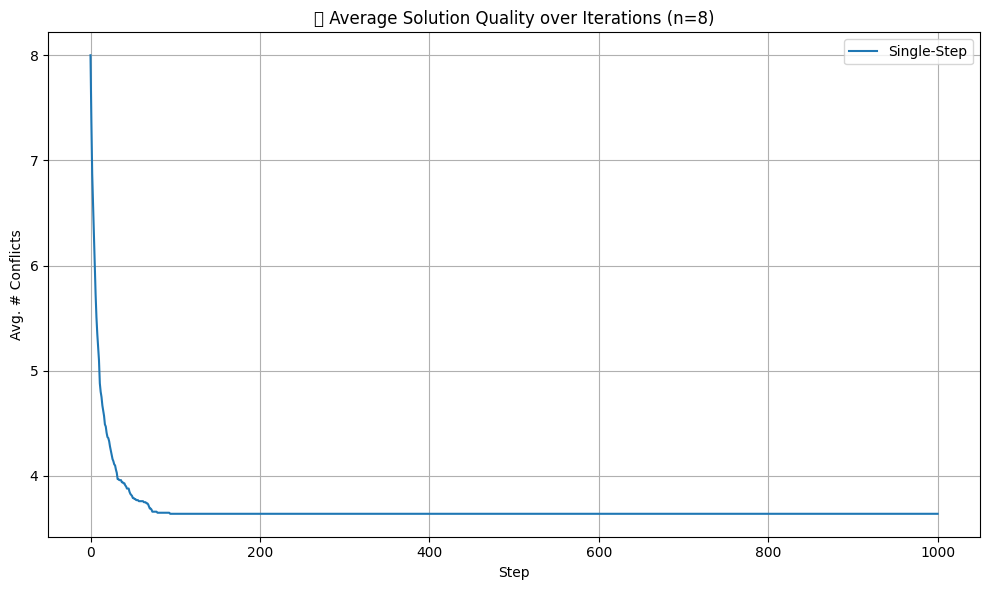

C:\Users\Acer\AppData\Local\Temp\ipykernel_20028\4095879041.py:102: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()


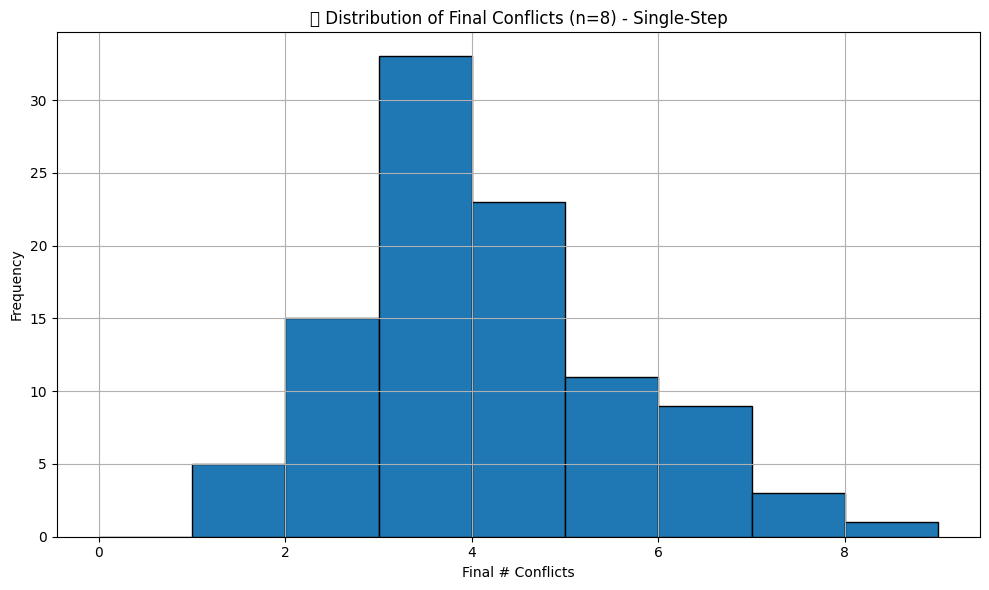

⚠️ Single-Step (n=8) - No successful runs


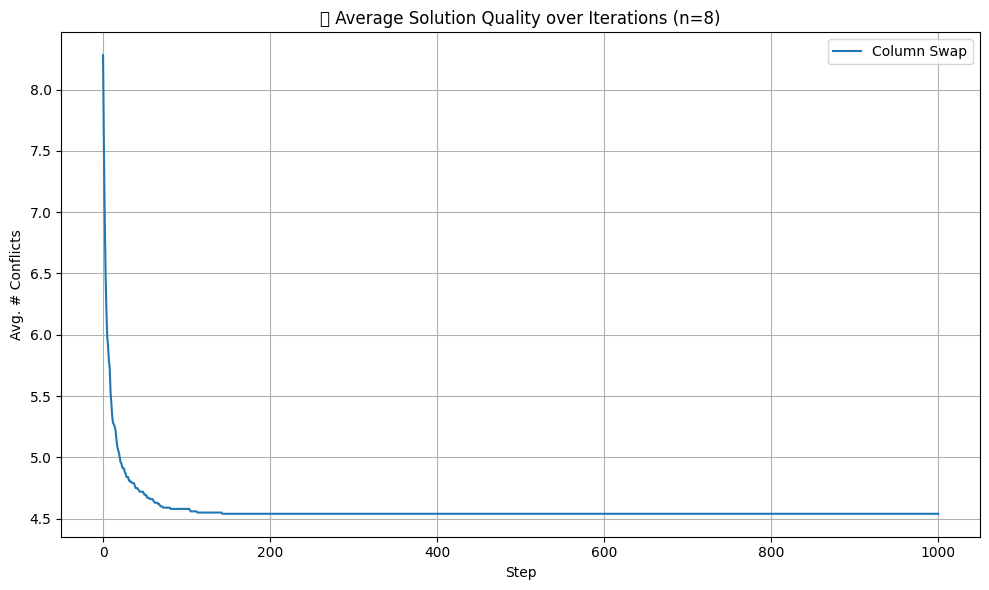

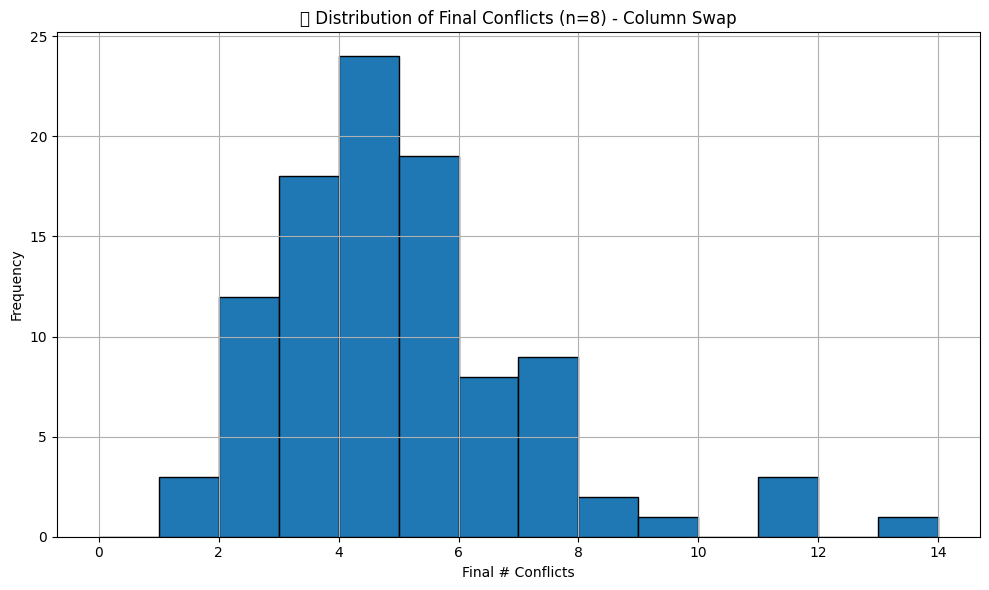

⚠️ Column Swap (n=8) - No successful runs


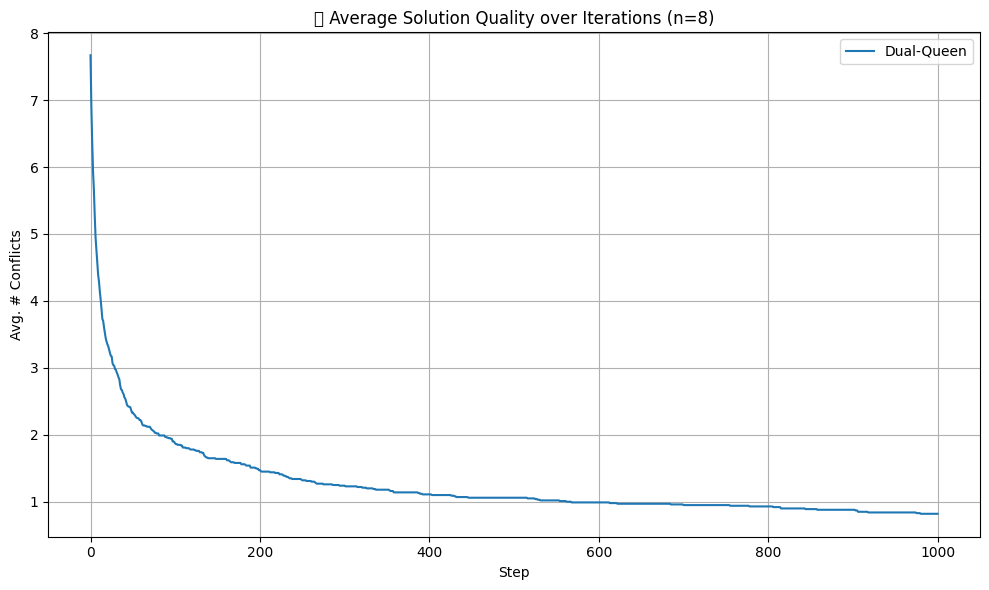

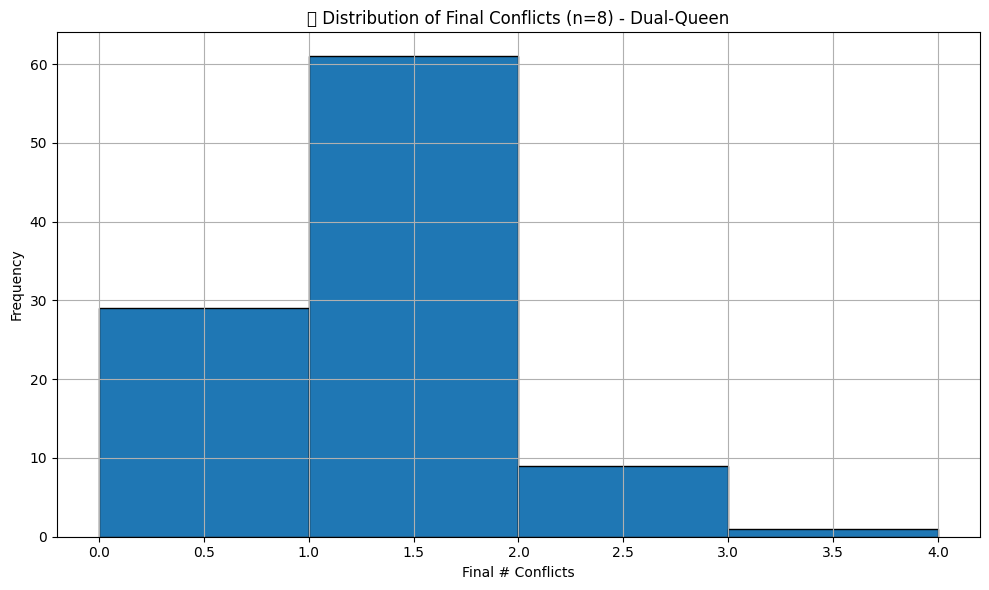

⏱️ Dual-Queen (n=8) - Avg. time for successful runs: 0.0184 seconds


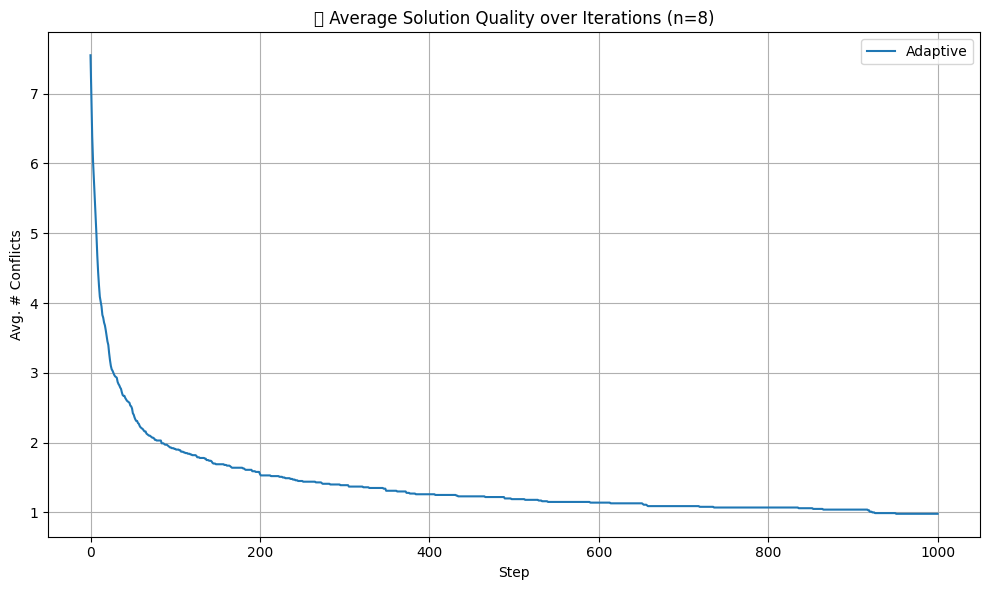

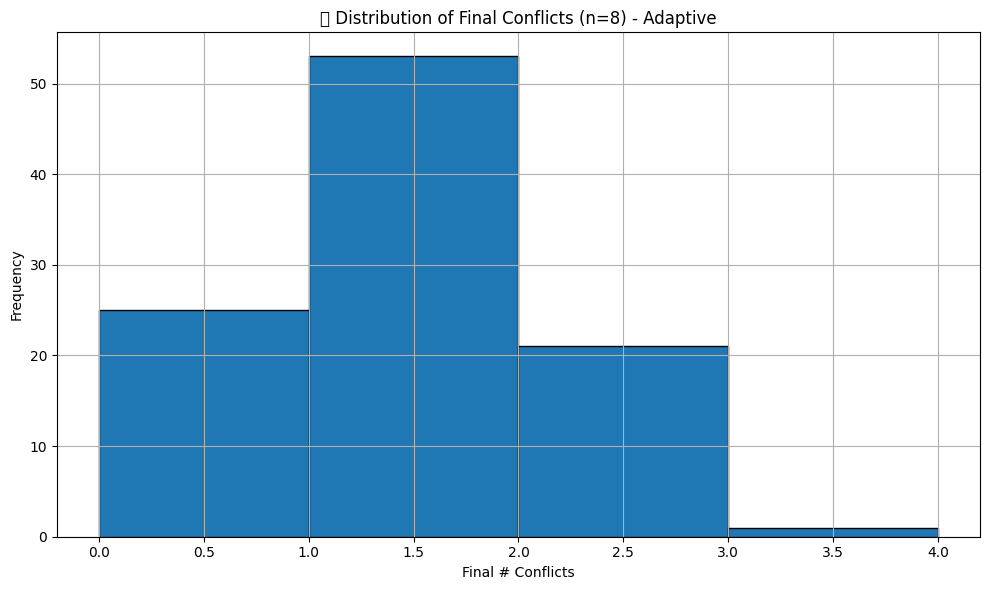

⏱️ Adaptive (n=8) - Avg. time for successful runs: 0.0400 seconds


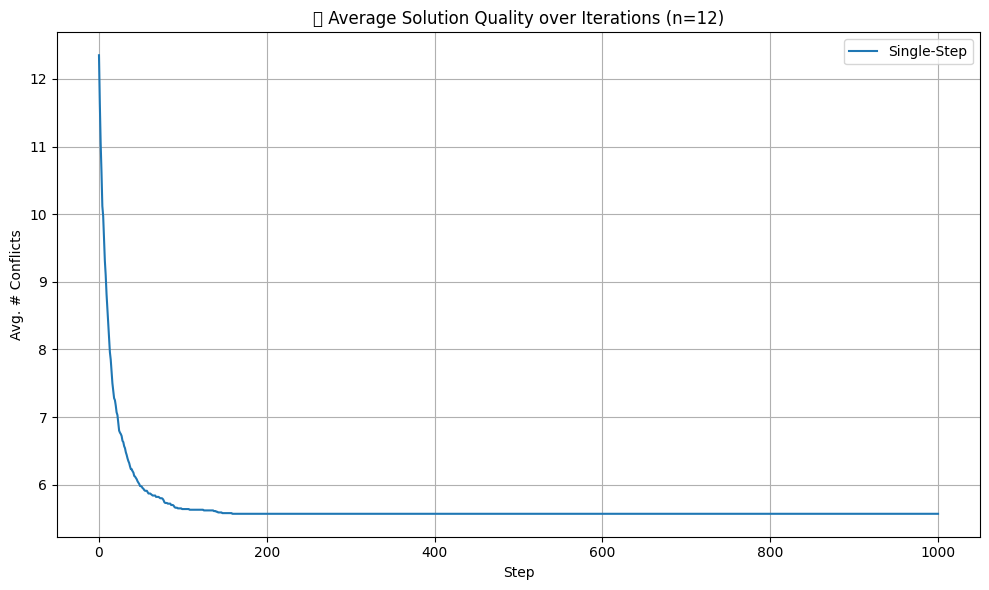

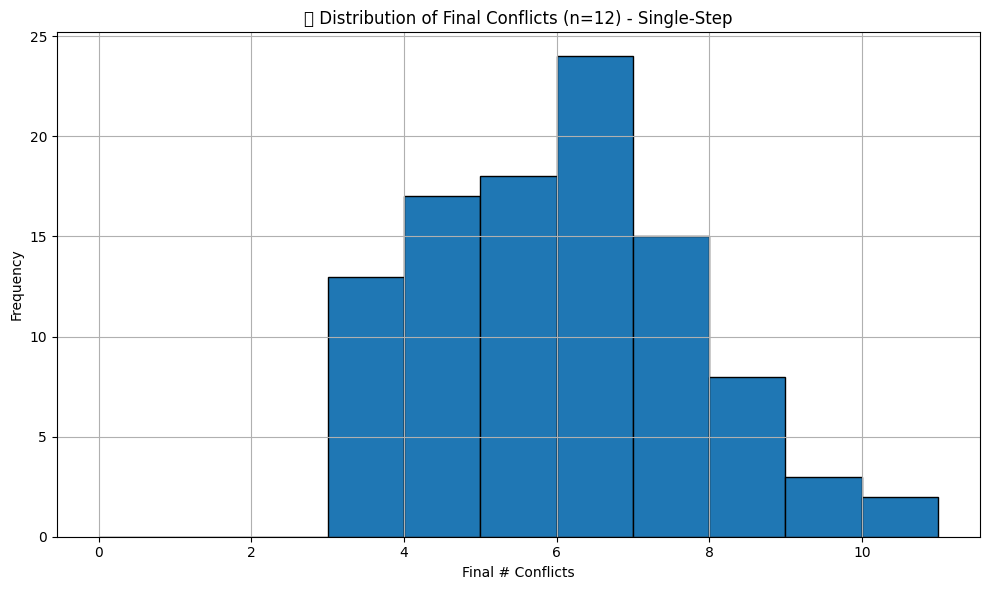

⚠️ Single-Step (n=12) - No successful runs


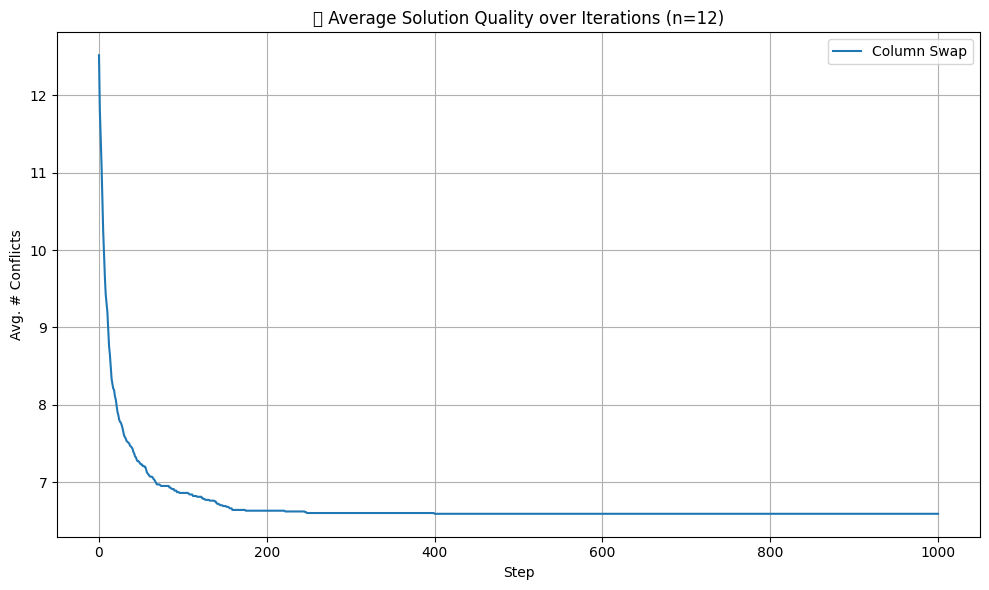

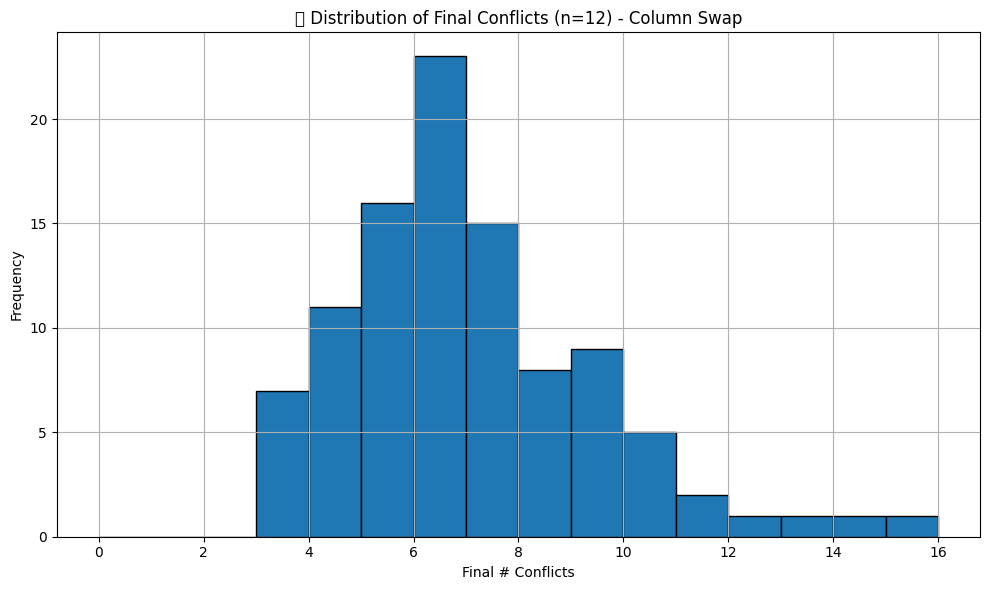

⚠️ Column Swap (n=12) - No successful runs


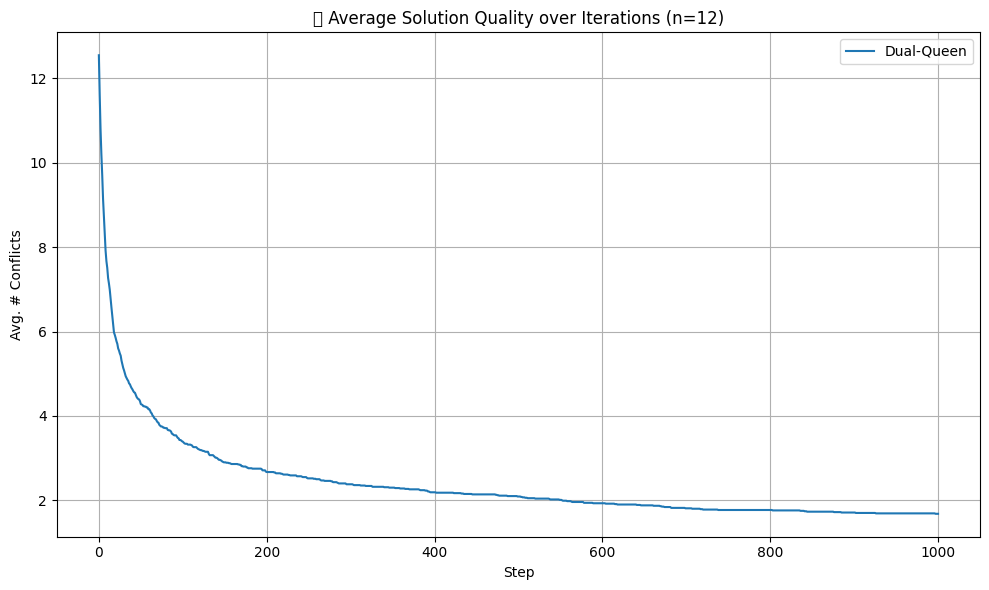

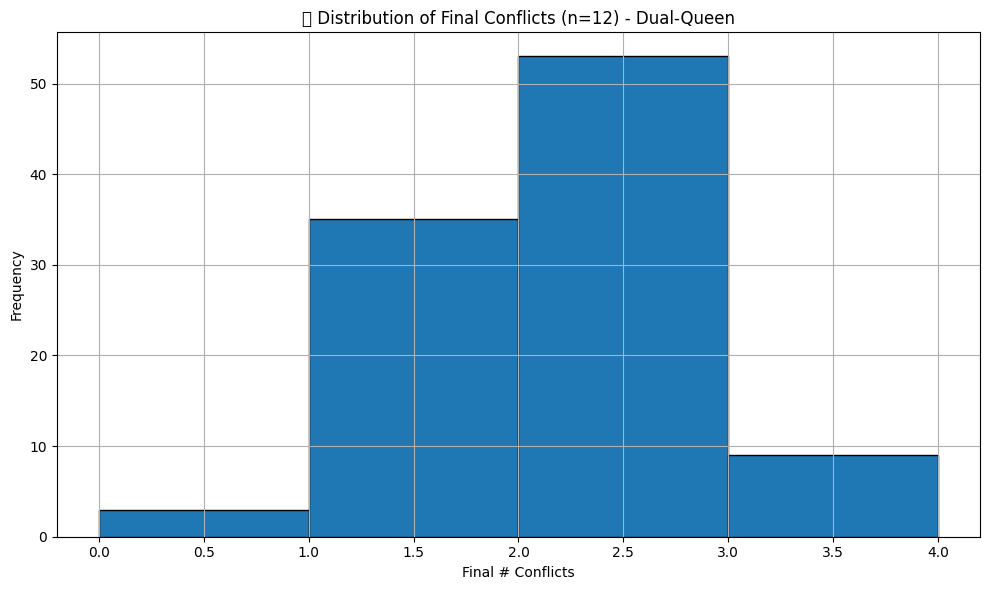

⏱️ Dual-Queen (n=12) - Avg. time for successful runs: 0.0367 seconds


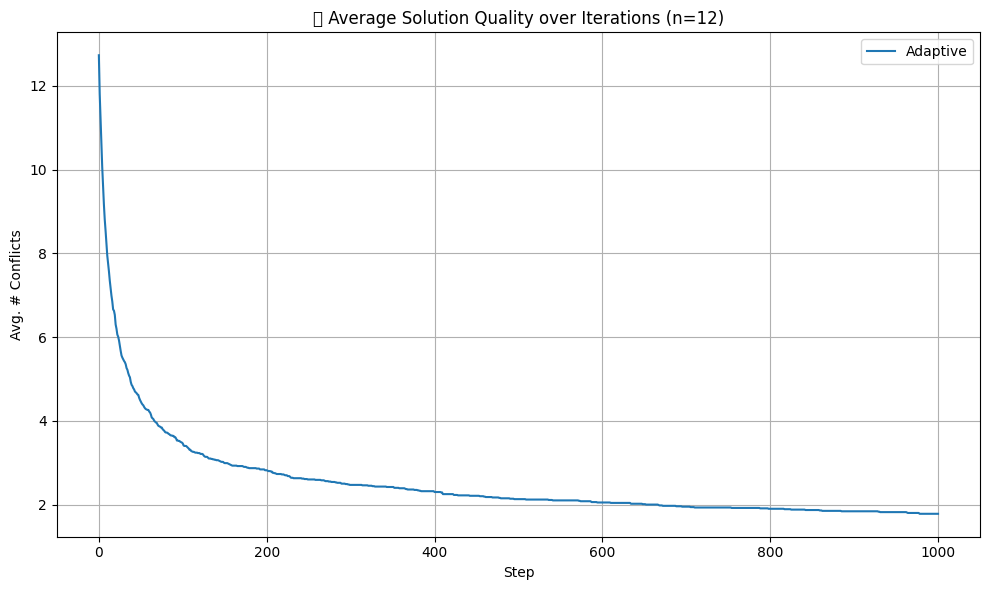

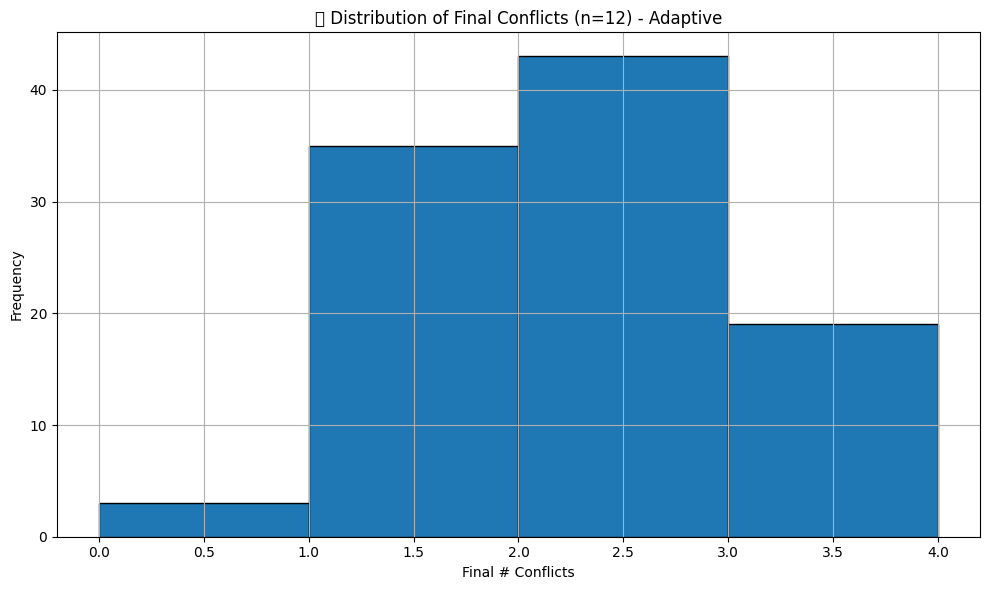

⏱️ Adaptive (n=12) - Avg. time for successful runs: 0.1220 seconds


In [34]:
# Code and description go here
import time 
def single_step_move(board):
    n = len(board)
    col = np.random.randint(n)
    direction = np.random.choice([-1, 1])
    new_board = board.copy()
    new_board[col] = max(0, min(n - 1, board[col] + direction))
    return new_board

def column_swap(board):
    n = len(board)
    c1, c2 = np.random.choice(n, 2, replace=False)
    new_board = board.copy()
    new_board[c1], new_board[c2] = new_board[c2], new_board[c1]
    return new_board

def dual_queen_move(board):
    n = len(board)
    cols = np.random.choice(n, 2, replace=False)
    new_board = board.copy()
    for col in cols:
        new_board[col] = np.random.randint(n)
    return new_board

def adaptive_move(board):
    n = len(board)
    conflict_counts = np.zeros(n)
    for i in range(n):
        for j in range(n):
            if i != j:
                if board[i] == board[j] or abs(board[i] - board[j]) == abs(i - j):
                    conflict_counts[i] += 1
    max_conflict_cols = np.where(conflict_counts == conflict_counts.max())[0]
    col = np.random.choice(max_conflict_cols)
    move_type = np.random.choice(['single', 'swap', 'dual'])

    if move_type == 'single':
        return single_step_move(board)
    elif move_type == 'swap':
        return column_swap(board)
    else:
        return dual_queen_move(board)

def stochastic_hc2_with_operator(n, move_func, max_steps=1000):
    board = random_board(n)
    conflict_history = [conflicts(board)]
    start_time = time.time()

    for _ in range(max_steps):
        current_conflicts = conflicts(board)
        if current_conflicts == 0:
            break

        new_board = move_func(board)
        new_conflicts = conflicts(new_board)

        if new_conflicts < current_conflicts:
            board = new_board
        conflict_history.append(conflicts(board))

    end_time = time.time()
    return board, conflict_history, end_time - start_time

import matplotlib.pyplot as plt

def run_experiment(n, move_func, label):
    histories = []
    final_conflicts = []
    times = []

    for _ in range(100):
        board, history, runtime = stochastic_hc2_with_operator(n, move_func)
        histories.append(history)
        final_conflicts.append(conflicts(board))
        if conflicts(board) == 0:
            times.append(runtime)

    # Trung bình theo bước
    max_len = max(len(h) for h in histories)
    padded = [h + [h[-1]] * (max_len - len(h)) for h in histories]
    avg_history = np.mean(padded, axis=0)

    # Vẽ biểu đồ
    plt.figure(figsize=(10, 6))
    plt.plot(avg_history, label=label)
    plt.title(f'📉 Average Solution Quality over Iterations (n={n})')
    plt.xlabel('Step')
    plt.ylabel('Avg. # Conflicts')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Phân phối nghiệm cuối
    plt.figure(figsize=(10, 6))
    plt.hist(final_conflicts, bins=range(0, max(final_conflicts)+2), edgecolor='black')
    plt.title(f'📊 Distribution of Final Conflicts (n={n}) - {label}')
    plt.xlabel('Final # Conflicts')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Thời gian trung bình cho nghiệm tối ưu
    if times:
        print(f'⏱️ {label} (n={n}) - Avg. time for successful runs: {np.mean(times):.4f} seconds')
    else:
        print(f'⚠️ {label} (n={n}) - No successful runs')

operators = {
    "Single-Step": single_step_move,
    "Column Swap": column_swap,
    "Dual-Queen": dual_queen_move,
    "Adaptive": adaptive_move
}

for n in [8, 12]:
    for label, func in operators.items():
        run_experiment(n, func, label)

## More Things to Do (not for credit)

If the assignment was to easy for yuo then you can think about the following problems. These problems are challenging and not part of this assignment. 

### Implement a Genetic Algorithm for the n-Queens problem

In [13]:
# Code and description go here